#### Análise da Votação - 2022

##### Obtendo dados e filtrando por número votáveis

In [8]:
# importar biblioteca polars
import polars as pl
import numpy as np
from matplotlib import pyplot as plt

pl.Config.set_tbl_rows(-1)
pl.Config.set_decimal_separator(',')
pl.Config.set_thousands_separator('.')
pl.Config.set_float_precision(2)


ENDERECO_DADOS = './../../DADOS/bolsa_familia/'
ENDERECO_VOTACAO = '../../DADOS/votacao/'

# obtendo dados:
try:
    df_bolsa_familia = pl.scan_parquet(ENDERECO_DADOS + 'bolsa_familia.parquet')
    df_dados_votacao = pl.read_csv(ENDERECO_VOTACAO + 'votacao_secao_2022_BR.csv', separator=';', encoding='latin1')

    # print(df_bolsa_familia.head(10))

    # verificando nome das colunas
    # print(df_dados_votacao.columns)

    # filtrar por segundo turno 'NR_TURNO' E NÚMERO VOTÁVEL 'NR_VOTAVEL' 13 E 22
    df_votacao_turno2 = df_dados_votacao.filter(
        (pl.col('NR_TURNO') == 2) & 
        (pl.col('NR_VOTAVEL').is_in([13, 22]))
    )
   
    print('Dados obtidos com sucesso!')
   
except Exception as e:
    print(f'Erro ao obter dados os dados: {e}')
    

Dados obtidos com sucesso!


##### Processamento Votação
Delimitando as variáveis, converter para Categorical, agrupar dados e totalizar

In [9]:
try:
    print('Processando os dados...')

    # demilitando 'SG_UF', 'NM_VOTAVEL', 'QT_VOTOS:
    df_votacao = df_votacao_turno2.lazy().select(['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS'])

    # converter para Categorical
    df_votacao = df_votacao.with_columns([
        pl.col('SG_UF').cast(pl.Categorical),
        pl.col('NM_VOTAVEL').cast(pl.Categorical)
    ])

    # agrupar por 'SG_UF' e 'NM_VOTAVEL' e somar 'QT_VOTOS'
    df_votacao = df_votacao.group_by(['SG_UF', 'NM_VOTAVEL']).agg(
        pl.sum('QT_VOTOS').alias('QT_VOTOS')
        ).sort('SG_UF', 'NM_VOTAVEL')
    
    
    # coletar dados e printar dados
    # df_votacao = df_votacao.collect()
    # display(df_votacao)
    print('Dados processados com sucesso!')

except Exception as e:
    print(f'Erro ao processar os dados: {e}')

Processando os dados...
Dados processados com sucesso!


##### Processando Bolsa Família

In [10]:
try:

    # selecionar 'UF' e 'VALOR PARCELA' usando lazy e select
    df_bolsa_familia = df_bolsa_familia.lazy().select(['UF', 'VALOR PARCELA'])

    # converter 'UF' para Categorical
    df_bolsa_familia = df_bolsa_familia.with_columns([
        pl.col('UF').cast(pl.Categorical)
    ])

    # agrupar por 'UF' e somar 'VALOR PARCELA'
    df_bolsa_familia = df_bolsa_familia.group_by('UF').agg(
        pl.sum('VALOR PARCELA').alias('VALOR PARCELA')
    ).sort('UF', descending=False)

    df_bolsa_familia = df_bolsa_familia.collect()
    print('Dados processados com sucesso!')

except Exception as e:
    print(f'Erro ao processar os dados: {e}')

Dados processados com sucesso!


##### Realizando o Merge dos dados

In [11]:
try:
    df_votos_bolsa_familia = (
        df_votacao.join(df_bolsa_familia, left_on='SG_UF', right_on='UF')
    )

    # Collect dos dados
    df_votos_bolsa_familia = df_votos_bolsa_familia.collect()
    
    # ordenar por 'SG_UF' e 'NM_VOTAVEL'
    # df_votos_bolsa_familia = df_votos_bolsa_familia.sort(['SG_UF', 'NM_VOTAVEL'])

    # display(df_votos_bolsa_familia)

except Exception as e:
    print(f'Erro ao realizar o merge os dados: {e}')

Erro ao realizar o merge os dados: expected `other` to be a 'LazyFrame', not 'DataFrame'


##### Correlação

In [12]:
try:
    # guardar a correlação dos candidatos
    dict_correlacoes = {}

    # calcular a correlação entre 'QT_VOTOS' e 'VALOR PARCELA' para cada candidato
    for candidato in df_votos_bolsa_familia['NM_VOTAVEL'].unique():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)
    
         # criar um arrays np 'Valor Parcela' e 'QT_VOTOS
        array_bolsa_familia = np.array(df_candidato['VALOR PARCELA'])
        array_votos = np.array(df_candidato['QT_VOTOS'])

        # calcular a correlação de Pearson
        correlacao = np.corrcoef(array_bolsa_familia, array_votos)[0, 1]

        # guardar a correlação no dicionário
        dict_correlacoes[candidato] = correlacao

        print(f'Correlação do candidato {candidato}: {correlacao:.2f}')

    print('\nCorrelação Calculada com sucesso!')
     
except Exception as e:
    print(f'Erro ao calcular a correlação: {e}')

Correlação do candidato LUIZ INÁCIO LULA DA SILVA: 0.89
Correlação do candidato JAIR MESSIAS BOLSONARO: 0.63

Correlação Calculada com sucesso!


##### Plotando os dados

Erro ao plotar os dados: 'DataFrame' object has no attribute 'collect'


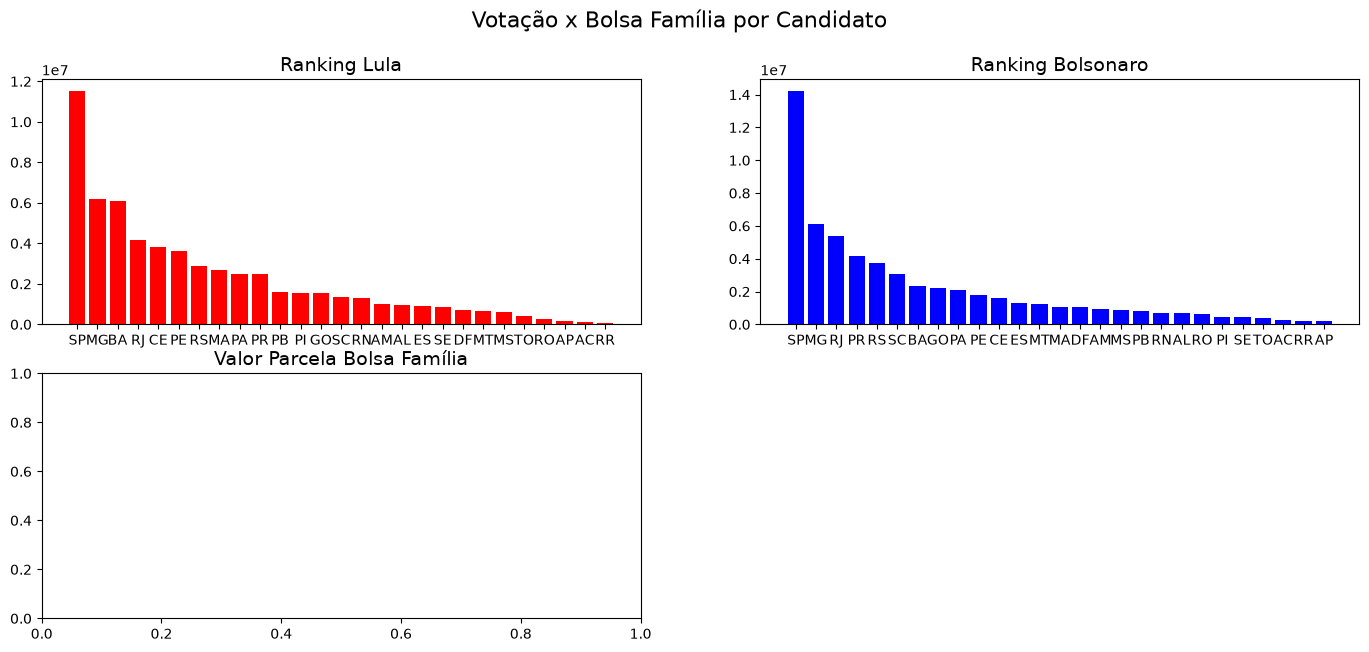

In [13]:
try:
    # plotando gráfico de dispersão
    fig = plt.figure(figsize=(17, 7))
    plt.suptitle('Votação x Bolsa Família por Candidato', fontsize=16)

    # Posição 1
    plt.subplot(2, 2, 1)
    # Ranking Luis Inácio Lula da Silva filtrar por 'NM_VOTAVEL' == 'LULA'
    df_lula = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'LUIZ INÁCIO LULA DA SILVA')
    df_lula = df_lula.sort('QT_VOTOS', descending=True)

    # Gráfico de colunas
    plt.bar(df_lula['SG_UF'], df_lula['QT_VOTOS'], color='red')
    plt.title('Ranking Lula', fontsize=14)

    # Posição 2
    plt.subplot(2, 2, 2)
    # Ranking Jair Messias Bolsonaro filtrar por 'NM_VOTAVEL' == 'BOLSONARO'
    df_bolsonaro = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'JAIR MESSIAS BOLSONARO')
    df_bolsonaro = df_bolsonaro.sort('QT_VOTOS', descending=True)
    plt.bar(df_bolsonaro['SG_UF'], df_bolsonaro['QT_VOTOS'], color='blue')
    plt.title('Ranking Bolsonaro', fontsize=14)

    # Posição 3
    plt.subplot(2, 2, 3)
    plt.title('Valor Parcela Bolsa Família', fontsize=14)
    df_bolsa_familia = df_bolsa_familia.sort('VALOR PARCELA', descending=True)
    plt.bar(df_bolsa_familia['UF'], df_bolsa_familia['VALOR PARCELA'], color='green')
    
    # Posição 4
    plt.subplot(2, 2, 4)
    plt.title('Correlação Votação x Bolsa Família', fontsize=14)
    x = 0.2
    y = 0.6

    for candidato, correlacao in dict_correlacoes.items():
        plt.text(x,y, f'Correlação {candidato}: {correlacao:.2f}', fontsize=12)
        y -= 0.2
         

    plt.show()
    print('\nGráfico plotado com sucesso!')
     
except Exception as e:
    print(f'Erro ao plotar os dados: {e}')